# Image processing, pt 3/3

In [3]:
# Libraries

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Library to load tiff files
import tifffile as tiff
# General math libraries
import numpy as np
from scipy import stats
# Image analysis libraries/modules
import skimage as sk
from scipy import ndimage


## Combining multiple operations


Let's load the bacterial data again:

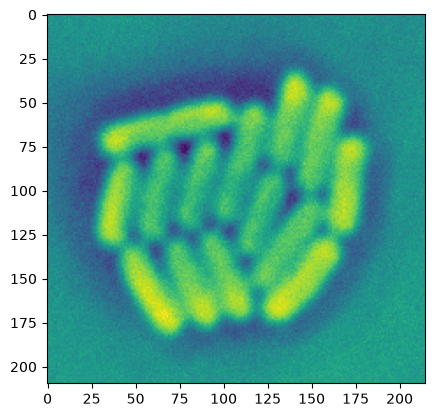

In [5]:
img_ecoli = np.invert(tiff.imread('images/microcolony_ecoli.tif'))
_ = plt.imshow(img_ecoli)

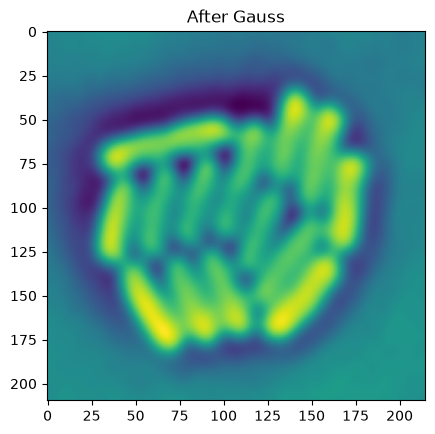

In [6]:
#### Laplacian + Gauss

# Now these can also be combined
# E.g. bacterial segmentation
    # we're interested in local edge detection

# Apply of LoG on the bacteria
img_ecoli_gauss = sk.filters.gaussian(img_ecoli, sigma=3)
edges_log = sk.filters.laplace(img_ecoli_gauss)

# show both
_ = plt.title("After Gauss")
_ = plt.imshow(img_ecoli_gauss)

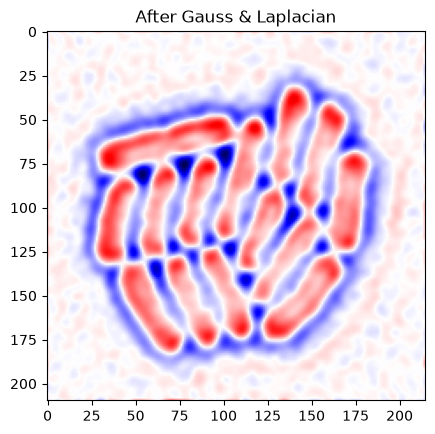

In [7]:

minmaxval = np.max(np.abs(edges_log))
_ = plt.title("After Gauss & Laplacian")
_ = plt.imshow(edges_log, cmap='seismic', vmin=-minmaxval, vmax=minmaxval)




As we saw above, edges correspond to values going from positive, through zero,
to negative. So we can look for places where negative and positive values are close.



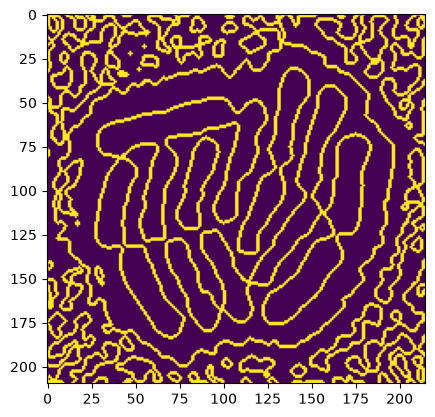

In [9]:
# Now identify edge pixels
    # where value goes positive->negative (or vice versa)
    # ie positive and negative value close

# per pixel, what's lowest and highest neighbor
edges_min = ndimage.minimum_filter(edges_log, footprint=sk.morphology.disk(1))
edges_pos = ndimage.maximum_filter(edges_log, footprint=sk.morphology.disk(1))
# do we find both positive & negative close?
img_edges = np.logical_and(edges_min < 0, edges_pos >0)

plt.imshow(img_edges)



Let's remove lines due to background noise by using a simpler triangle mask to select the colony.



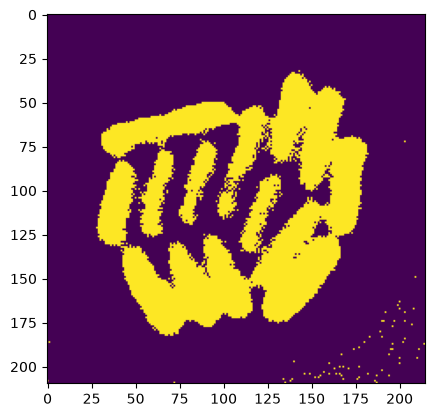

In [13]:

# Use previous thresholded image 
    # Make whole-colony mask    
mask_ecoli_triangle = img_ecoli > sk.filters.threshold_triangle(img_ecoli)

_ = plt.imshow(mask_ecoli_triangle)


/var/folders/8w/2thz_cgn3xn13rhrxb2dvb5w0000gn/T/ipykernel_10645/1907258506.py:5: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  sk.morphology.remove_small_objects(


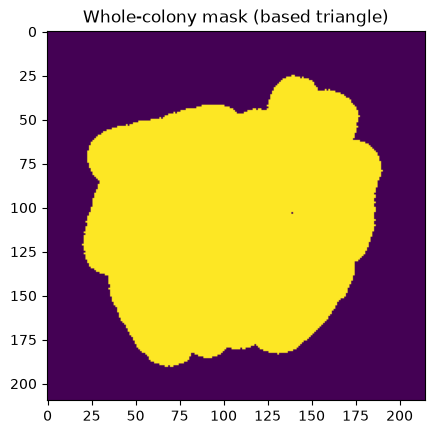

In [14]:
# Modify this mask

# Remove small parts
mask_ecoli_triangle_filtered = \
    sk.morphology.remove_small_objects(
        mask_ecoli_triangle, 
        min_size=50
    )
# Enlarge it
mask_ecoli_triangle_filtered = \
    sk.morphology.dilation(
        mask_ecoli_triangle_filtered, 
        footprint=sk.morphology.disk(8)
    )

_ = plt.title("Whole-colony mask (based triangle)")
_ = plt.imshow(mask_ecoli_triangle_filtered)


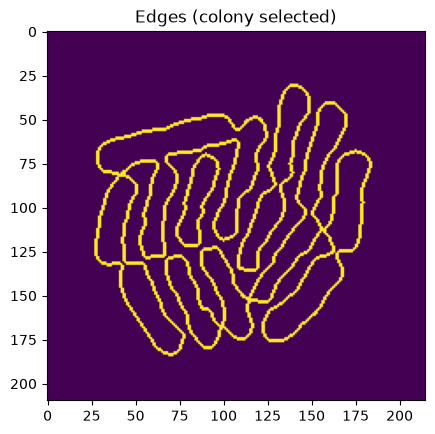

In [15]:
# Combine both
img_edges_foreground = np.logical_and(img_edges, mask_ecoli_triangle_filtered)
_ = plt.title("Edges (colony selected)")
_ = plt.imshow(img_edges_foreground)



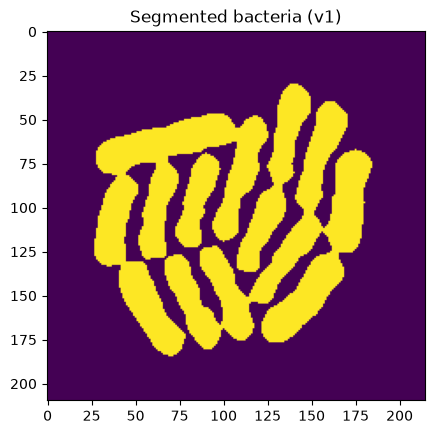

In [ ]:
# And fill outlines
img_edges_filled = ndimage.binary_fill_holes(img_edges_foreground)
_ = plt.title("Segmented bacteria (v1)")
_ = plt.imshow(img_edges_filled)

This looks pretty great, except that some bacteria are still "stuck together".

Let's try to identify separate bacteria.

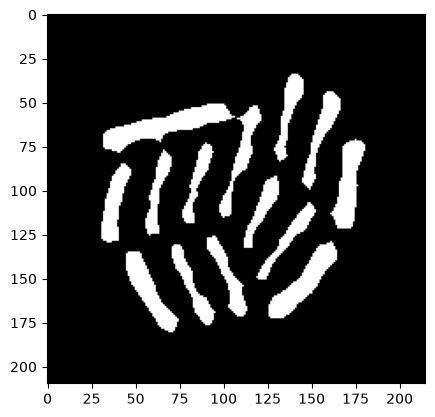

In [17]:
# Let's erode this by 4 px
# (Aim: get indivdual bacterial locations)
mask_ecoli_log_eroded = \
    sk.morphology.erosion(
        img_edges_filled, 
        footprint=sk.morphology.disk(4)
    )

# Show
_ = plt.imshow(mask_ecoli_log_eroded, cmap='gray')

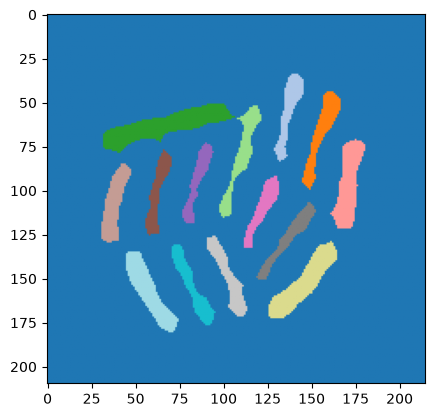

In [18]:
# And label
mask_bacteria_slim_labeled = sk.measure.label(mask_ecoli_log_eroded)
_ = plt.imshow(mask_bacteria_slim_labeled, cmap='tab20')


<img src=figures/puddles.png height=200px>
<img src=figures/watershed.jpg height=200px>

*(Pictures via user24124133 and [researchgate](http://dx.doi.org/10.3390/rs6010776).)  Watershed is a common algorithm to segment touching objects. It is inspired by how water would fill up a landscape. From specific seeds, the water level rises, and once separate regions touch, boundaries are established.*



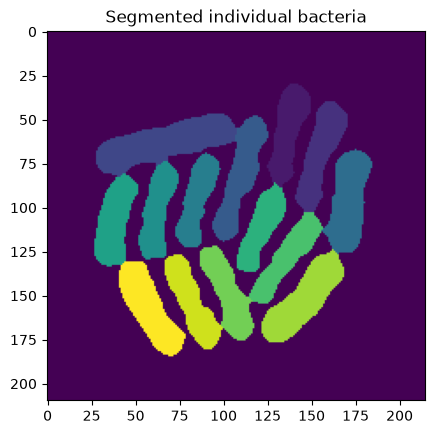

In [21]:
# Apply to separate bacteria
    # Using mask_ecoli_log
    # mask_bacteria_slim_labeled as seeds
mask_bacteria_combined = \
    sk.segmentation.watershed(
        -1*img_edges_filled, 
        markers=mask_bacteria_slim_labeled, 
        mask=img_edges_filled
    )

# Show the result
_ = plt.title("Segmented individual bacteria")
_ = plt.imshow(mask_bacteria_combined, cmap='viridis')

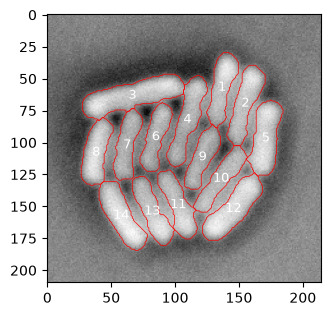

In [20]:
# Polish the final image a little bit

# Let's get regionprops from mask_bacteria_combined
props = sk.measure.regionprops(mask_bacteria_combined)

# Plot it
fig, ax = plt.subplots(1,1, figsize=(9/2.54,9/2.54))
_ = ax.imshow(img_ecoli, cmap='gray')
# slightly shaded region
# plt.imshow(mask_bacteria_combined, cmap='jet', alpha= .3*(mask_bacteria_combined>0))
# project numbered labels on top
for x,y,lbl in [(p.centroid[1], p.centroid[0], p.label) for p in props]:
    # centered text
    ax.text(x, y, str(lbl), color='white', fontsize=9, ha='center', va='center')
    # specific bacterial outline
    ax.contour(mask_bacteria_combined==lbl, colors='red', linewidths=0.5)

Identical to mask_bacteria_combined: True


/var/folders/8w/2thz_cgn3xn13rhrxb2dvb5w0000gn/T/ipykernel_10645/531234188.py:21: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  sk.morphology.remove_small_objects(mask_ecoli_triangle, min_size=min_size)


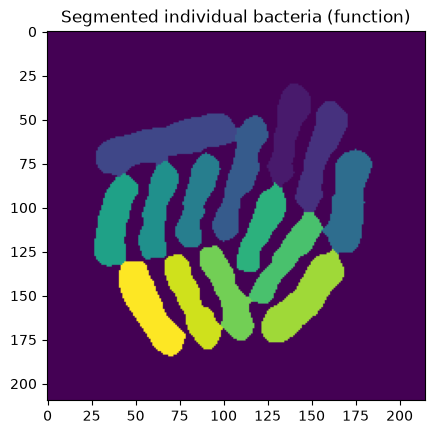

In [24]:
# Test the function
mask_bacteria_fn = segment_bacteria(img_ecoli)

# Should give the same result as the step-by-step approach
print("Identical to mask_bacteria_combined:", np.array_equal(mask_bacteria_fn, mask_bacteria_combined))

_ = plt.title("Segmented individual bacteria (function)")
_ = plt.imshow(mask_bacteria_fn, cmap='viridis')

<div align=center><img src=figures/exercise.png width=10%></div>

## Exercise: Batch analysis of the KTR data

- Download the file `KTR-images-series.zip`, which contains the following folders:
    - `sensor/`
        - `KTR_sensor_frame_0000.tif`
        - `KTR_sensor_frame_0001.tif`
        - (..)
    - `nuclei/`
        - `KTR_nuclei_frame_0000.tif`
        - `KTR_nuclei_frame_0001.tif`
        - (..)
- Use a loop to write these images into one big `np.array()`.
- Write a function that calculates the KTR C/N ratio, like we did in part 2
    - The function should take as input arguments `img_nuclei` and `img_KTR`, respectively data from a single frame of nuclei or KTR sensor image data.
    - The function should then return all C/N ratios from that image
- Use a loop to apply this function to all time points of the data.
- Plot the data (either using `matplotlib`, or `seaborn` and a `pandas` dataframe).